# 01 — Laden des Datensatzes
Wir laden den "Porto Seguro's Safe Driver Prediction" Datensatz direkt von OpenML (ID: 42742). Dieser Datensatz enthält Informationen über Versicherungsnehmer, wobei das Ziel darin besteht, vorherzusagen, ob ein Fahrer im nächsten Jahr einen Versicherungsanspruch stellen wird.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Laden der Daten von OpenML
bunch = fetch_openml(data_id=42742, as_frame=True, parser='auto')
df = bunch.frame

print(f"Datensatz erfolgreich geladen: {df.shape[0]} Zeilen und {df.shape[1]} Spalten.")

Datensatz erfolgreich geladen: 595212 Zeilen und 58 Spalten.


# 02 — Analyse der Zielvariablen (Target Balance)
Ein wichtiger Aspekt bei Versicherungsdaten ist das Klassenungleichgewicht (Class Imbalance). Wir prüfen, wie viele Fahrer tatsächlich einen Schaden gemeldet haben (`target=1`) im Vergleich zu denen, die keinen Schaden hatten (`target=0`).

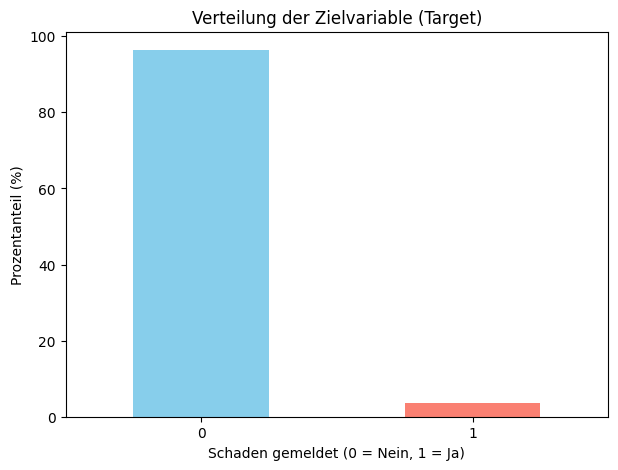

Anteil der Fahrer mit Schaden (Klasse '1'): 3.64%


In [11]:
# Berechnung der Anteile
target_counts = df['target'].value_counts(normalize=True) * 100

# Sicherstellen, dass der Index als String interpretiert wird
target_counts.index = target_counts.index.astype(str)

# Sortieren nach Index ('0' vor '1') für eine saubere Grafik
target_counts = target_counts.sort_index()

plt.figure(figsize=(7, 5))
target_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Verteilung der Zielvariable (Target)')
plt.xlabel('Schaden gemeldet (0 = Nein, 1 = Ja)')
plt.ylabel('Prozentanteil (%)')
plt.xticks(rotation=0)
plt.show()

# Zugriff über den String-Key '1'
print(f"Anteil der Fahrer mit Schaden (Klasse '1'): {target_counts['1']:.2f}%")

# 03 — Analyse fehlender Werte
In dieser Version des Datensatzes sind fehlende Werte bereits als `NaN` kodiert. Wir identifizieren die Features mit den höchsten Fehlraten, um später entscheiden zu können, welche Spalten entfernt oder imputiert werden müssen.

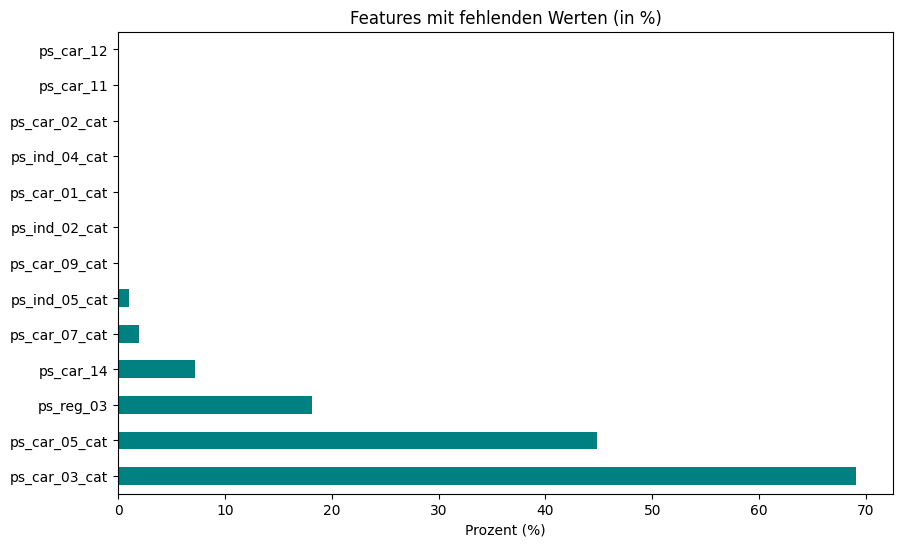

In [12]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False)

if not missing_df.empty:
    missing_df.plot(kind='barh', figsize=(10, 6), color='teal')
    plt.title('Features mit fehlenden Werten (in %)')
    plt.xlabel('Prozent (%)')
    plt.show()
else:
    print("Keine fehlenden Werte gefunden.")

# 04 — Feature-Distribution (Einzelanalyse)
Wir untersuchen die Verteilung einzelner Merkmale (z.B. `ps_ind_01`), um Ausreißer zu identifizieren und die Struktur der Daten besser zu verstehen.

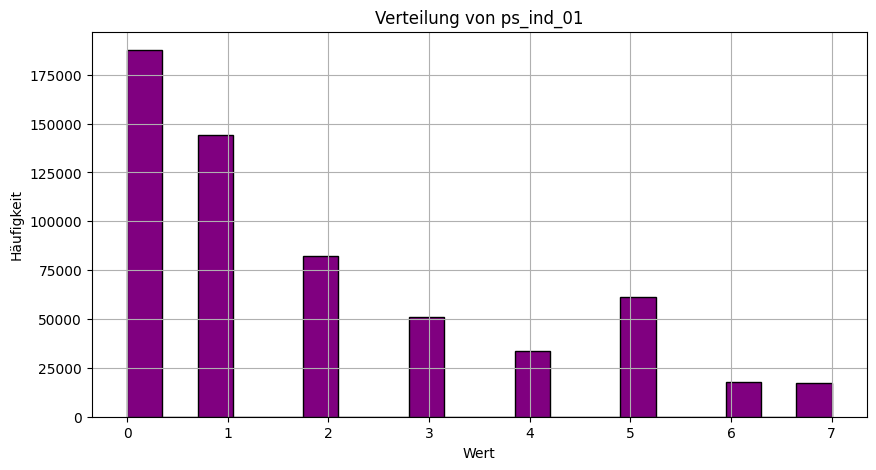

In [13]:
plt.figure(figsize=(10, 5))
df['ps_ind_01'].hist(bins=20, color='purple', edgecolor='black')
plt.title('Verteilung von ps_ind_01')
plt.xlabel('Wert')
plt.ylabel('Häufigkeit')
plt.show()

# 05 — Korrelations-Heatmap
Um die Beziehungen zwischen den numerischen Variablen zu verstehen, erstellen wir eine Korrelationsmatrix. Dies hilft uns, redundante Features (Multikollinearität) zu finden.

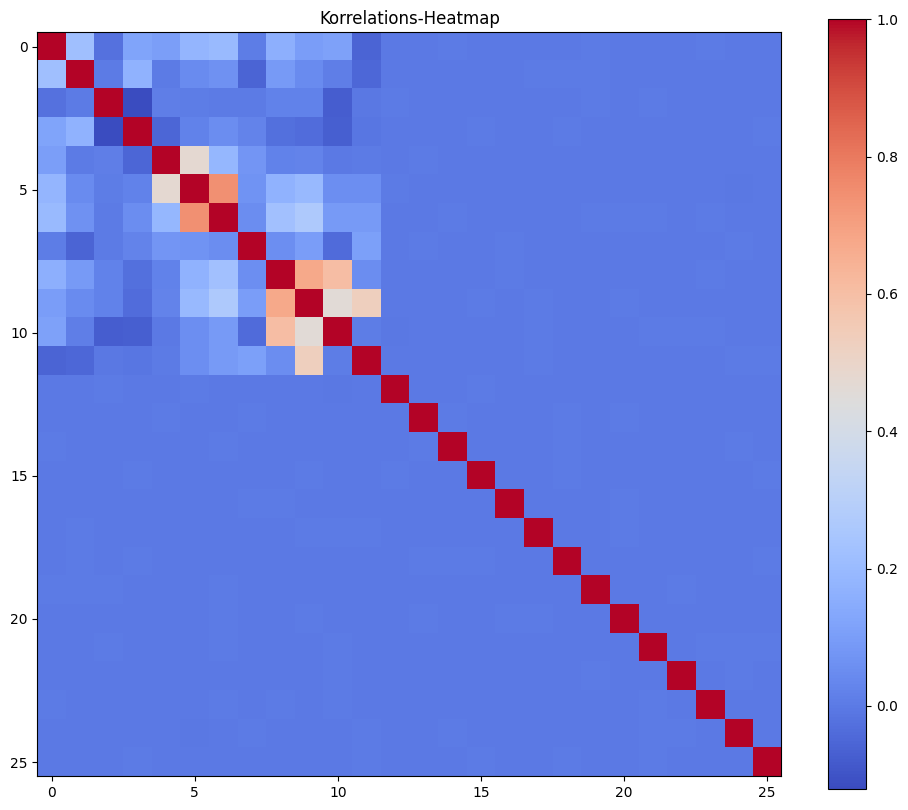

In [14]:
# Nur numerische Spalten für die Korrelation nutzen
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.title('Korrelations-Heatmap')
plt.show()

# 06 — Beziehung der Features zum Target
Schließlich untersuchen wir, wie sich bestimmte Features auf die Wahrscheinlichkeit eines Schadens auswirken. Dies ist der wichtigste Teil der explorativen Analyse (Bivariate Analyse).

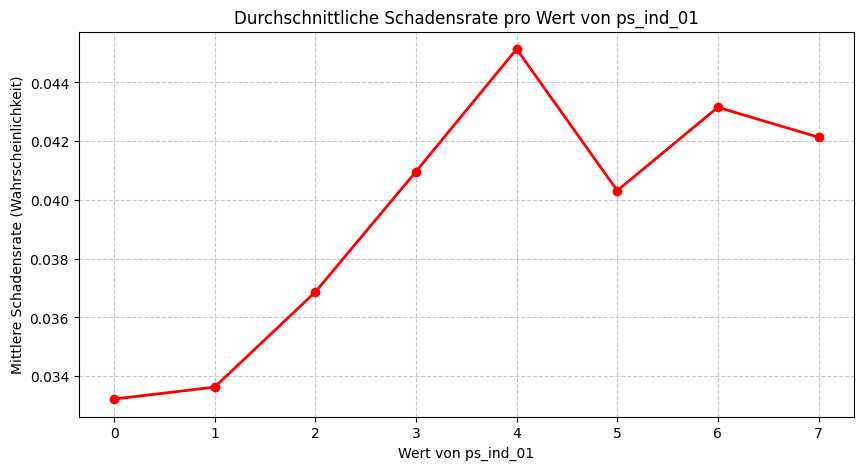

Durchschnittliche Werte pro Kategorie:
ps_ind_01
0.0    0.033221
1.0    0.033629
2.0    0.036863
3.0    0.040963
4.0    0.045132
5.0    0.040316
6.0    0.043151
7.0    0.042131
Name: target, dtype: float64


In [16]:
# Wir konvertieren das Target temporär in Float, um den Mittelwert berechnen zu können
# Das 'target' von OpenML ist oft ein String ('0', '1')
target_float = df['target'].astype(float)

# Gruppierung nach 'ps_ind_01' und Berechnung der mittleren Schadensrate
mean_target = target_float.groupby(df['ps_ind_01']).mean()

# Visualisierung
plt.figure(figsize=(10, 5))
mean_target.plot(kind='line', marker='o', color='red', linewidth=2)

plt.title('Durchschnittliche Schadensrate pro Wert von ps_ind_01', fontsize=12)
plt.xlabel('Wert von ps_ind_01')
plt.ylabel('Mittlere Schadensrate (Wahrscheinlichkeit)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Durchschnittliche Werte pro Kategorie:")
print(mean_target)

## 07 — Modelltraining und Datenvorbereitung

In diesem Schritt bereiten wir die Daten endgültig vor. Wir führen einen **Train-Test-Split** (80/20) durch und imputieren fehlende Werte mit dem Median. Anschließend trainieren wir den **RandomForestClassifier**. Um eine Überanpassung zu vermeiden, begrenzen wir die Tiefe der Bäume (`max_depth=10`).

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

# 1. Split
X = df.drop('target', axis=1)
y = df['target'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Imputation
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 3. Training
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_imputed, y_train)

print("Training abgeschlossen!")

Training abgeschlossen!


## 08 — Visualisierung der Confusion Matrix

Die Confusion Matrix zeigt uns die Leistung des Modells im Detail. Da unser Datensatz imbalanced ist, ist es wichtig zu sehen, wie viele tatsächliche Schadensfälle (Klasse 1) korrekt identifiziert wurden.

<Figure size 800x600 with 0 Axes>

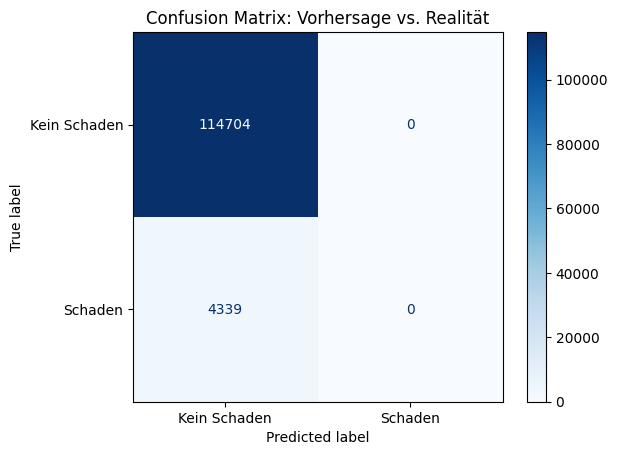

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_test_imputed)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Kein Schaden', 'Schaden'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Vorhersage vs. Realität')
plt.show()

## 09 — Visualisierung der Feature Importance

Ein großer Vorteil des Random Forest ist die Interpretierbarkeit. Wir visualisieren hier die 10 wichtigsten Merkmale, die das Modell zur Vorhersage von Versicherungsansprüchen nutzt. Dies schließt den Kreis zu unserer vorherigen EDA.

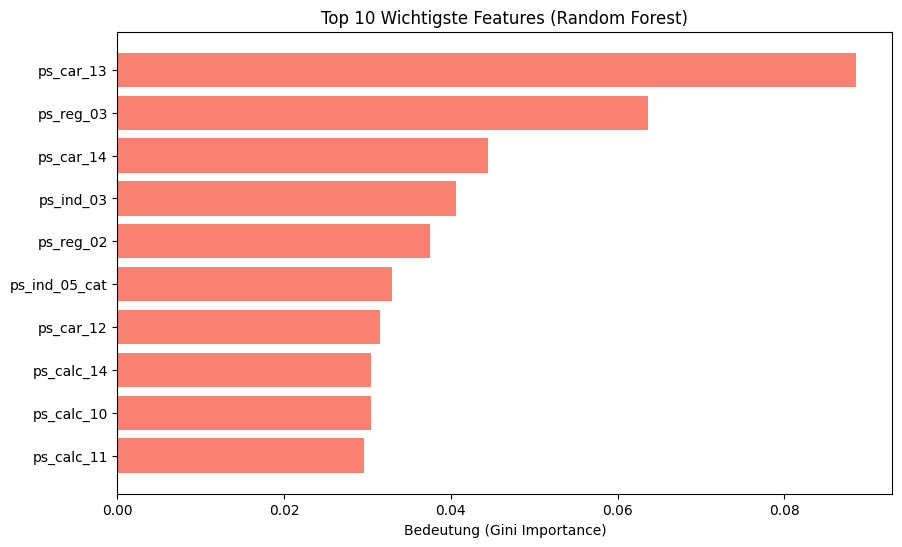

In [19]:
import pandas as pd

# Wichtigkeiten extrahieren
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plotten
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='salmon')
plt.gca().invert_yaxis()
plt.title('Top 10 Wichtigste Features (Random Forest)')
plt.xlabel('Bedeutung (Gini Importance)')
plt.show()

## 10 — Modellvalidierung: AUC-ROC und Gini-Koeffizient

Nachdem wir die wichtigsten Merkmale identifiziert haben, müssen wir die Modellgüte objektiv bewerten. Da unser Datensatz ein starkes Klassenungleichgewicht aufweist (imbalanced data), ist die reine Trefferquote (Accuracy) nicht aussagekräftig.

In der Versicherungsbranche ist der **Gini-Koeffizient** das Standardmaß zur Bewertung von Risikomodellen. Er misst die Trennschärfe zwischen Versicherten mit und ohne Schadensfall. Ein Gini-Wert von 0 entspricht dem Zufall, während ein Wert von 1 ein perfektes Modell darstellt.

Wir berechnen den Gini-Koeffizienten direkt aus der Fläche unter der ROC-Kurve (AUC) mit der Formel:
**Gini = 2 * AUC - 1**

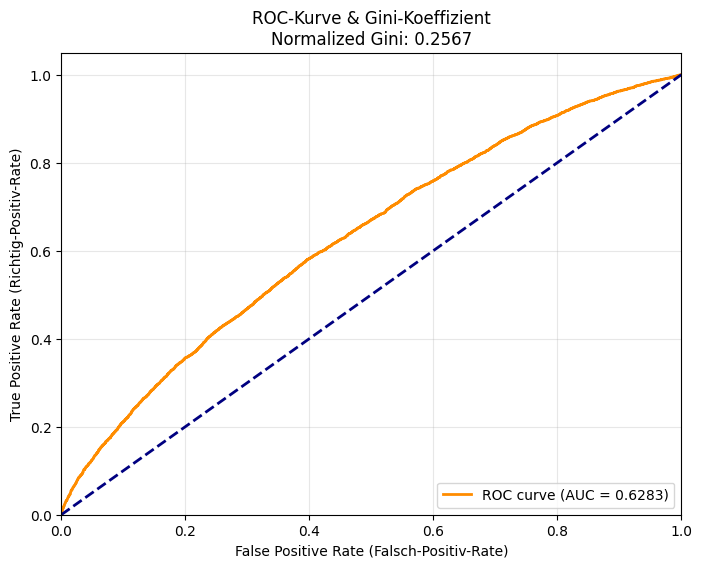

Berechneter Gini-Koeffizient für dieses Modell: 0.2567


In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Vorhersage-Wahrscheinlichkeiten für die Klasse 1 (Schaden) berechnen
y_probs = rf_model.predict_proba(X_test_imputed)[:, 1]

# 2. AUC und ROC-Kurve berechnen
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Gini-Koeffizient berechnen
gini_score = 2 * roc_auc - 1

# 4. Visualisierung der ROC-Kurve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Falsch-Positiv-Rate)')
plt.ylabel('True Positive Rate (Richtig-Positiv-Rate)')
plt.title(f'ROC-Kurve & Gini-Koeffizient\nNormalized Gini: {gini_score:.4f}')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Berechneter Gini-Koeffizient für dieses Modell: {gini_score:.4f}")